PROGRAM 3 

original shape: (150, 4)
reduced shape: (150, 2)


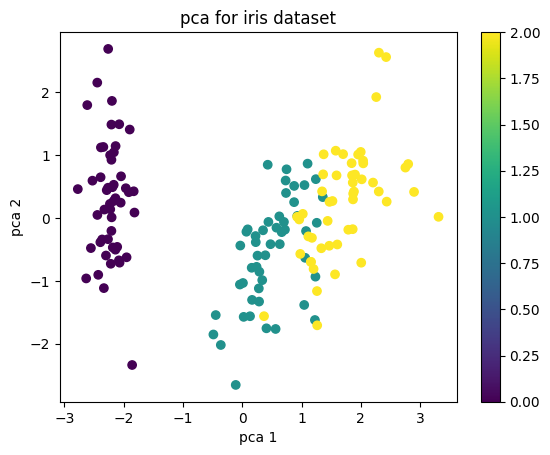

In [7]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
iris= load_iris()
x=iris.data
y=iris.target
x_scaled= StandardScaler().fit_transform(x)
x_pca= PCA(n_components=2).fit_transform(x_scaled)
print("original shape:", x.shape)
print("reduced shape:", x_pca.shape)

#scatter plot
plt.scatter(x_pca[:,0], x_pca[:,1],c=y, cmap='viridis')
plt.title("pca for iris dataset")
plt.xlabel("pca 1")
plt.ylabel("pca 2")
plt.colorbar()
plt.show()

PROGRAM 4 

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

X,y=load_iris(return_X_y=True)
X=StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42)

for k in[1,3,5]:
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred=knn.predict(X_test)
    print(f"\nregular knn: k={k}\n")
    print("accuracy_score:",accuracy_score(y_test,pred))
    print("f1_score:",f1_score(y_test,pred,average="macro"))

    #weighted knn
    wknn=KNeighborsClassifier(n_neighbors=k, weights='distance')
    wknn.fit(X_train, y_train)
    pred_w=wknn.predict(X_test)
    print(f"weightes knn: k={k}\n")
    print("accuracy_score:",accuracy_score(y_test,pred_w))
    print("f1_score:",f1_score(y_test,pred_w,average="macro"))

    


regular knn: k=1

accuracy_score: 0.9777777777777777
f1_score: 0.974320987654321
weightes knn: k=1

accuracy_score: 0.9777777777777777
f1_score: 0.974320987654321

regular knn: k=3

accuracy_score: 1.0
f1_score: 1.0
weightes knn: k=3

accuracy_score: 1.0
f1_score: 1.0

regular knn: k=5

accuracy_score: 1.0
f1_score: 1.0
weightes knn: k=5

accuracy_score: 1.0
f1_score: 1.0


PROGRAM 6

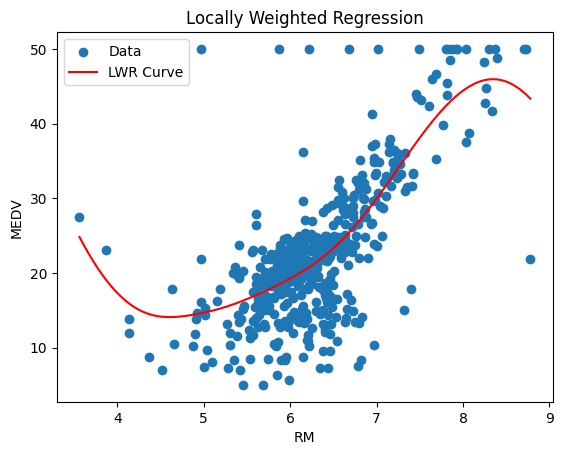

In [23]:
#PROGRAM 6
# pip install pandas numpy matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("BostonHousing.csv")

X = df["rm"].values
y = df["medv"].values

def lwr(x0, tau=0.5):
    Xb = np.c_[np.ones(len(X)), X]
    w = np.exp(-(X - x0)**2 / (2 * tau**2))
    W = np.diag(w)

    theta = np.linalg.pinv(Xb.T @ W @ Xb) @ Xb.T @ W @ y
    return np.array([1, x0]) @ theta

X_test = np.linspace(min(X), max(X), 200)
y_pred = [lwr(x) for x in X_test]

plt.scatter(X, y, label="Data")
plt.plot(X_test, y_pred, 'r', label="LWR Curve")
plt.xlabel("RM")
plt.ylabel("MEDV")
plt.title("Locally Weighted Regression")
plt.legend()
plt.show()

PROGRAM 7 : linear regression, polynomial regression

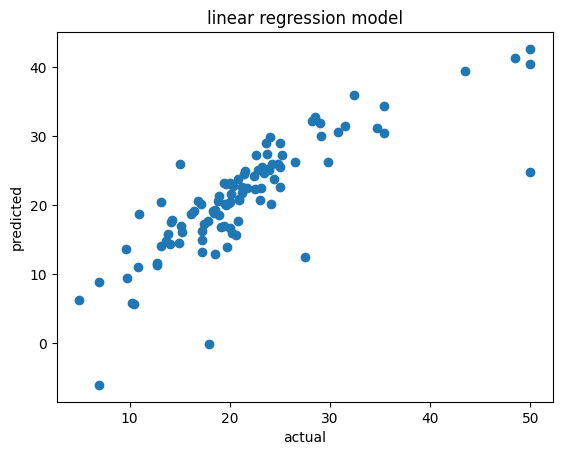

r2_score: 0.6687594935356317
mean_squared_error: 24.291119474973538


In [46]:
#linear regression
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.linear_model import LinearRegression

df=pd.read_csv("BostonHousing.csv")
x=df.drop('medv', axis=1)
y=df['medv']
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.2, random_state=42)

model=LinearRegression()
model.fit(x_train, y_train)
y_pred= model.predict(x_test)

plt.scatter(y_test, y_pred)
plt.title("linear regression model")
plt.xlabel("actual")
plt.ylabel("predicted")
plt.show()

print("r2_score:", r2_score(y_test, y_pred))
print("mean_squared_error:", mean_squared_error(y_test, y_pred))

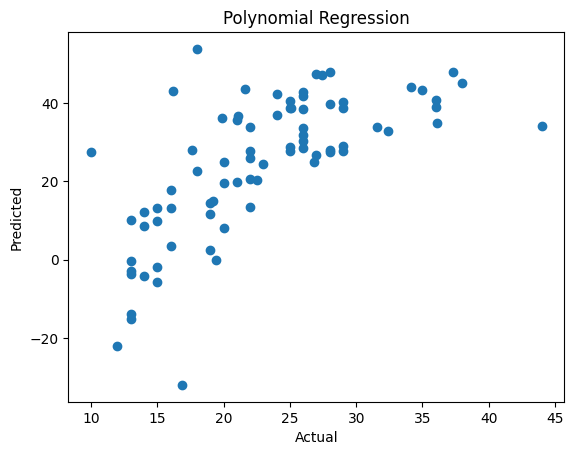

R2 Score: -2.9282696525321423
Mean Squared Error: 200.50117418870397


In [56]:
#polynomial regression
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

df = pd.read_csv("auto-mpg.csv")

df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df.dropna(inplace=True)

if 'car name' in df.columns:
    df.drop('car name', axis=1, inplace=True)

X = df.drop('mpg', axis=1)
y = df['mpg']

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression()
model.fit(X_train_poly, y_train)
y_pred = model.predict(X_test_poly)

plt.scatter(y_test, y_pred)
plt.title("Polynomial Regression")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))